# Getting started with FiftyOne Datasets

## Content overview

In this tutorial we cover the following concepts:

- [Dataset basics and samples](https://beta-docs.voxel51.com/getting_started/basic/datasets_samples_fields/)
- [Detection fields and labels](https://beta-docs.voxel51.com/api/fiftyone.core.labels.Detection.html)
- [Dataset views and filtering](https://beta-docs.voxel51.com/how_do_i/cheat_sheets/filtering_cheat_sheet/)
- [Computing and visualizing image embeddings with CLIP](https://docs.voxel51.com/tutorials/image_embeddings.html)

## Who is this for

This tutorial is designed for:

* Computer vision practitioners who are new to the FiftyOne app
* Anyone looking to integrate annotations into their visual datasets for analysis

## Assumed knowledge

- Basic knowledge of image processing
- Intermediate Python programming
- Experience working with Jupyter notebooks

## Estimated time to complete
30-45 minutes

## Required packages for local installation

If not running from a Google Colab environment, we recommend using a virtual environment with [FiftyOne installed](https://beta-docs.voxel51.com/getting_started/basic/install/).



Run this cell to install FiftyOne on Google Colab.

In [1]:
!pip install fiftyone==1.5.2 -q > /dev/null

Import the FiftyOne library and check the version that has been installed.

In [2]:
import fiftyone as fo
fo.__version__

'1.5.2'

## Inspecting the quickstart `Dataset`

In the FiftyOne dataset zoo, we have a collection of publicly available datasets that can be easily loaded and used for computer vision tasks. The `quickstart` dataset is a small subset of 200 images from the COCO 2017 validation set with ground truth annotations and object detections that is great for demonstrating the features of FiftyOne.

In [3]:
# Import the FiftyOne zoo for loading datasets.
import fiftyone.zoo as foz

#When we specify `persistent = True`, we make sure that changes to the dataset
# are saved across multiple Python sessions.
dataset = foz.load_zoo_dataset("quickstart", persistent=False)

INFO:fiftyone.zoo.datasets:Downloading dataset to '/root/fiftyone/quickstart'


INFO:fiftyone.zoo.datasets.base:Downloading dataset...


 100% |████|  187.5Mb/187.5Mb [116.9ms elapsed, 0s remaining, 1.6Gb/s]        


INFO:eta.core.utils: 100% |████|  187.5Mb/187.5Mb [116.9ms elapsed, 0s remaining, 1.6Gb/s]        


Extracting dataset...


...

INFO:fiftyone.zoo.datasets:Loading 'quickstart'


 100% |█████████████████| 200/200 [12.1s elapsed, 0s remaining, 32.7 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 200/200 [12.1s elapsed, 0s remaining, 32.7 samples/s]      


Dataset 'quickstart' created


INFO:fiftyone.zoo.datasets:Dataset 'quickstart' created


In case that we want to revert to the original state of the dataset,
we can evaluate `dataset = dataset_clone` later in the notebook.

In [4]:
# Creates a backup copy of the dataset (without copying the image files)
dataset_clone = dataset.clone()

We can use the `stats()` method on a dataset to obtain info about its number of samples and size on disk.

In [5]:
dataset.stats()

{'samples_count': 200,
 'samples_bytes': 1279162,
 'samples_size': '1.2MB',
 'total_bytes': 1279162,
 'total_size': '1.2MB'}

The `info` field in the dataset can be used to add extra metadata. Here we are using it to specify where we got the dataset from and its license (Creative Commons 4.0).

In [6]:
dataset.info["dataset_source"] = "https://docs.voxel51.com/dataset_zoo/datasets.html#dataset-zoo-quickstart"
dataset.info["dataset_license"] = "CC-BY-4.0"
dataset.info

{'dataset_source': 'https://docs.voxel51.com/dataset_zoo/datasets.html#dataset-zoo-quickstart',
 'dataset_license': 'CC-BY-4.0'}

`.count()` tells us how many samples have been added to the dataset.

In [7]:
dataset.count()

200

In FiftyOne, a sample is an image and all its associated tags, metadata, and annotations.

In [8]:
sample=dataset.first()
sample

<Sample: {
    'id': '682c592489f949d21d433d16',
    'media_type': 'image',
    'filepath': '/root/fiftyone/quickstart/data/000880.jpg',
    'tags': ['validation'],
    'metadata': None,
    'created_at': datetime.datetime(2025, 5, 20, 10, 27, 48, 424000),
    'last_modified_at': datetime.datetime(2025, 5, 20, 10, 27, 48, 424000),
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '5f452471ef00e6374aac53c8',
                'attributes': {},
                'tags': [],
                'label': 'bird',
                'bounding_box': [0.21084375, 0.0034375, 0.46190625, 0.9442083333333334],
                'mask': None,
                'mask_path': None,
                'confidence': None,
                'index': None,
                'area': 73790.37944999996,
                'iscrowd': 0.0,
            }>,
            <Detection: {
                'id': '5f452471ef00e6374aac53c9',
                'attributes': {},
               

## FiftyOne sample fields

In FiftyOne, a field is an attribute associated with each sample (e.g., image or video) in a dataset. Fields store labels, metadata, predictions, or custom data. Fields provide a way to organize and access information about your data within the FiftyOne framework. You can use fields to filter, sort, and analyze your dataset. Fields play a role in tasks like model evaluation and data visualization. Some examples of built-in fields are `filepath`, `ground_truth`, and `predictions`, but you can also define your own custom fields to store any data you need.



Here we can inspect the fields of the sample.

In [9]:
sample.field_names

('id',
 'filepath',
 'tags',
 'metadata',
 'created_at',
 'last_modified_at',
 'ground_truth',
 'uniqueness',
 'predictions')

The ID of the sample is a hash that is unique for each image.

In [10]:
sample.id

'682c592489f949d21d433d16'

We have a datetime object specifying when the dataset was created by us on disk.

In [11]:
sample.created_at

datetime.datetime(2025, 5, 20, 10, 27, 48, 424000)

`sample.ground_truth` specifies the labels and positions of our object detections.

In [12]:
sample.ground_truth

<Detections: {
    'detections': [
        <Detection: {
            'id': '5f452471ef00e6374aac53c8',
            'attributes': {},
            'tags': [],
            'label': 'bird',
            'bounding_box': [0.21084375, 0.0034375, 0.46190625, 0.9442083333333334],
            'mask': None,
            'mask_path': None,
            'confidence': None,
            'index': None,
            'area': 73790.37944999996,
            'iscrowd': 0.0,
        }>,
        <Detection: {
            'id': '5f452471ef00e6374aac53c9',
            'attributes': {},
            'tags': [],
            'label': 'bird',
            'bounding_box': [0.74946875, 0.489375, 0.2164375, 0.23183333333333334],
            'mask': None,
            'mask_path': None,
            'confidence': None,
            'index': None,
            'area': 3935.7593000000006,
            'iscrowd': 0.0,
        }>,
        <Detection: {
            'id': '5f452471ef00e6374aac53ca',
            'attributes': {},
     

`sample.predictions` will give us the list of all bounding boxes that have been computed on the dataset already. Note that each detection has a unique hash ID, a label, a confidence level, and an associated bounding box. Note that we are accessing the first sample from the *clone*. Later in the notebook we will delete the predictions field from the original sample. This cell is accessing the backup version of the dataset.

In [13]:
sample = dataset_clone.first()
sample.predictions

<Detections: {
    'detections': [
        <Detection: {
            'id': '5f452c60ef00e6374aad9394',
            'attributes': {},
            'tags': [],
            'label': 'bird',
            'bounding_box': [
                0.22192673683166503,
                0.06093006531397502,
                0.4808845520019531,
                0.8937615712483724,
            ],
            'mask': None,
            'mask_path': None,
            'confidence': 0.9750854969024658,
            'index': None,
        }>,
        <Detection: {
            'id': '5f452c60ef00e6374aad9395',
            'attributes': {},
            'tags': [],
            'label': 'bird',
            'bounding_box': [
                0.3962469816207886,
                0.006943931678930918,
                0.27418792247772217,
                0.46793556213378906,
            ],
            'mask': None,
            'mask_path': None,
            'confidence': 0.759726881980896,
            'index': None,
        

Notice that the `sample.filepath` points to the path to the image on the hard drive. `filepath` is the only required sample field when creating our own datasets.

In [14]:
sample.filepath

'/root/fiftyone/quickstart/data/000880.jpg'

As the file is local, we can open it with PIL, NumPy or PyTorch.

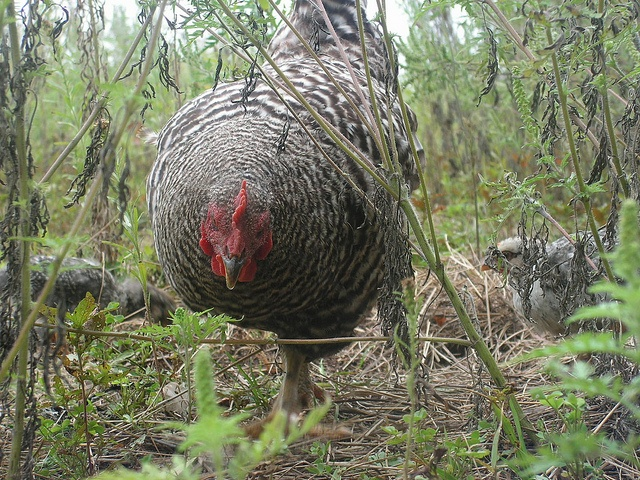

In [15]:
from PIL import Image
original_sample = Image.open(sample.filepath)
original_sample

We can add fields to our sample, in order to extend it.

In [16]:
sample['inspected_in_notebook'] = True
sample.field_names

('id',
 'filepath',
 'tags',
 'metadata',
 'created_at',
 'last_modified_at',
 'ground_truth',
 'uniqueness',
 'predictions',
 'inspected_in_notebook')

We can also add the field at the dataset level.

In [17]:
dataset.add_sample_field("inspected_in_notebook", fo.BooleanField)

In FiftyOne, files are loaded from disk. The images from the `quickstart` dataset are now on the hard drive of the computer running this notebook.

In [18]:
from pathlib import Path
!ls {Path(sample.filepath).parent}

000002.jpg  000889.jpg	001851.jpg  002598.jpg	003754.jpg  004416.jpg
000008.jpg  000890.jpg	001867.jpg  002640.jpg	003769.jpg  004431.jpg
000020.jpg  000939.jpg	001888.jpg  002645.jpg	003805.jpg  004510.jpg
000031.jpg  000957.jpg	001934.jpg  002660.jpg	003870.jpg  004514.jpg
000035.jpg  000998.jpg	001949.jpg  002671.jpg	003871.jpg  004517.jpg
000058.jpg  001047.jpg	001951.jpg  002748.jpg	003880.jpg  004525.jpg
000083.jpg  001057.jpg	001983.jpg  002799.jpg	003888.jpg  004534.jpg
000089.jpg  001073.jpg	002015.jpg  002823.jpg	003911.jpg  004535.jpg
000145.jpg  001078.jpg	002022.jpg  002869.jpg	003964.jpg  004546.jpg
000164.jpg  001118.jpg	002063.jpg  002905.jpg	003969.jpg  004548.jpg
000191.jpg  001133.jpg	002070.jpg  002906.jpg	003978.jpg  004557.jpg
000192.jpg  001147.jpg	002086.jpg  002939.jpg	004039.jpg  004585.jpg
000400.jpg  001154.jpg	002121.jpg  002953.jpg	004066.jpg  004590.jpg
000436.jpg  001191.jpg	002129.jpg  003084.jpg	004082.jpg  004610.jpg
000452.jpg  001227.jpg	002143.jpg 

When evaluating the dataset object, we get a quick look at its attributes.

In [19]:
dataset

Name:        quickstart
Media type:  image
Num samples: 200
Persistent:  False
Tags:        []
Sample fields:
    id:                    fiftyone.core.fields.ObjectIdField
    filepath:              fiftyone.core.fields.StringField
    tags:                  fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:              fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:            fiftyone.core.fields.DateTimeField
    last_modified_at:      fiftyone.core.fields.DateTimeField
    ground_truth:          fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    uniqueness:            fiftyone.core.fields.FloatField
    predictions:           fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    inspected_in_notebook: fiftyone.core.fields.BooleanField

Our dataset consists of images and we have 200 samples of them.

In [20]:
dataset.media_type, len(dataset)

('image', 200)

## Adding samples to the dataset

Let's create a grayscale variation of the image above

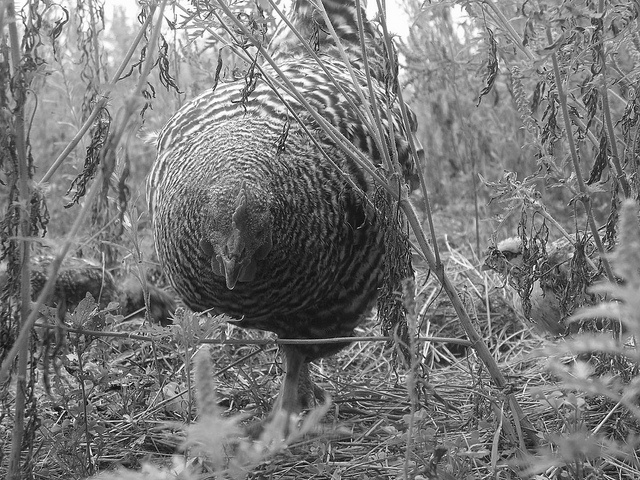

In [21]:
grayscale_sample = Image.open(sample.filepath).convert("L")
grayscale_sample

We save it on the same location as the original file.

In [22]:
save_folder = Path(sample.filepath).parent
grayscale_sample_filename = save_folder / "grayscale.png"
grayscale_sample.save(grayscale_sample_filename)

In [23]:
# Create a new sample for the grayscale image
grayscale_sample_entry = fo.Sample(filepath=str(grayscale_sample_filename))

# Add the new sample to the dataset
dataset.add_samples([grayscale_sample_entry])

# Verify that the sample was added
print(f"Number of samples after adding grayscale: {len(dataset)}")

 100% |█████████████████████| 1/1 [6.7ms elapsed, 0s remaining, 388.5 samples/s] 


INFO:eta.core.utils: 100% |█████████████████████| 1/1 [6.7ms elapsed, 0s remaining, 388.5 samples/s] 


Number of samples after adding grayscale: 201


The new sample automatically receives an id from a hash function.

In [24]:
grayscale_sample_entry.id

'682c593189f949d21d433ddf'

Let's mark it as inspected inside the notebook.

In [25]:
grayscale_sample_entry.inspected_in_notebook = True


Launch the FiftyOne App and load the full dataset into it.

In [26]:
session = fo.launch_app(dataset, auto=False)
print(f"Click on the URL to access the FiftyOne app {session.url}")

Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.



Welcome to

███████╗██╗███████╗████████╗██╗   ██╗ ██████╗ ███╗   ██╗███████╗
██╔════╝██║██╔════╝╚══██╔══╝╚██╗ ██╔╝██╔═══██╗████╗  ██║██╔════╝
█████╗  ██║█████╗     ██║    ╚████╔╝ ██║   ██║██╔██╗ ██║█████╗
██╔══╝  ██║██╔══╝     ██║     ╚██╔╝  ██║   ██║██║╚██╗██║██╔══╝
██║     ██║██║        ██║      ██║   ╚██████╔╝██║ ╚████║███████╗
╚═╝     ╚═╝╚═╝        ╚═╝      ╚═╝    ╚═════╝ ╚═╝  ╚═══╝╚══════╝ v1.5.2

If you're finding FiftyOne helpful, here's how you can get involved:

|
|  ⭐⭐⭐ Give the project a star on GitHub ⭐⭐⭐
|  https://github.com/voxel51/fiftyone
|
|  🚀🚀🚀 Join the FiftyOne Discord community 🚀🚀🚀
|  https://community.voxel51.com/
|



INFO:fiftyone.core.session.session:
Welcome to

███████╗██╗███████╗████████╗██╗   ██╗ ██████╗ ███╗   ██╗███████╗
██╔════╝██║██╔════╝╚══██╔══╝╚██╗ ██╔╝██╔═══██╗████╗  ██║██╔════╝
█████╗  ██║█████╗     ██║    ╚████╔╝ ██║   ██║██╔██╗ ██║█████╗
██╔══╝  ██║██╔══╝     ██║     ╚██╔╝  ██║   ██║██║╚██╗██║██╔══╝
██║     ██║██║        ██║      ██║   ╚██████╔╝██║ ╚████║███████╗
╚═╝     ╚═╝╚═╝        ╚═╝      ╚═╝    ╚═════╝ ╚═╝  ╚═══╝╚══════╝ v1.5.2

If you're finding FiftyOne helpful, here's how you can get involved:

|
|  ⭐⭐⭐ Give the project a star on GitHub ⭐⭐⭐
|  https://github.com/voxel51/fiftyone
|
|  🚀🚀🚀 Join the FiftyOne Discord community 🚀🚀🚀
|  https://community.voxel51.com/
|



Click on the URL to access the FiftyOne app https://5151-m-s-2dnue5v4k6hrf-c.us-west1-0.prod.colab.dev?polling=true


## Removing fields from a dataset

We have used the FiftyOne app to inspect the ground truth and the pre-computed predictions from an object detection model.

To remove the ground_truth and predictions fields from your dataset, we can use the `delete_sample_fields()` method. This method takes a list of field names as input and removes them from all samples in the dataset.

In [27]:
# This operation happens in-place, it can evaluated once
dataset.delete_sample_fields(["predictions" , "uniqueness"])

In [28]:
dataset

Name:        quickstart
Media type:  image
Num samples: 201
Persistent:  False
Tags:        []
Sample fields:
    id:                    fiftyone.core.fields.ObjectIdField
    filepath:              fiftyone.core.fields.StringField
    tags:                  fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:              fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:            fiftyone.core.fields.DateTimeField
    last_modified_at:      fiftyone.core.fields.DateTimeField
    ground_truth:          fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    uniqueness:            fiftyone.core.fields.FloatField
    inspected_in_notebook: fiftyone.core.fields.BooleanField

In [29]:
# The fields are no longer visible through the session
session = fo.launch_app(dataset, auto=False)
print(session.url)

Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.


https://5151-m-s-2dnue5v4k6hrf-c.us-west1-0.prod.colab.dev?polling=true


# Clone vs. Views in FiftyOne Datasets

In FiftyOne, both clones and views provide ways to work with datasets, but they serve different purposes:

## Clones

A clone is a complete copy of a dataset. When we clone a dataset in FiftyOne:

- Changes made to the clone do not affect the original dataset
- Clones are independent datasets with their own names in FiftyOne's MongoDB database
- All samples, fields, and metadata are fully copied into a clone

Here's how we would create a clone:




Create a named clone.

In [30]:
cloned_dataset = dataset.clone("my-quickstart-clone")

The named clone will now appear in the list of available datasets, alongside the unnamed clone that we created at the start of the notebook and the quickstart.

In [31]:
fo.list_datasets()

['2025.05.20.10.28.00.383496', 'my-quickstart-clone', 'quickstart']

In [32]:
cloned_dataset.first().filepath

'/root/fiftyone/quickstart/data/000880.jpg'

## Views

A view is a filtered subset of the FiftyOne dataset. When when we create a view:

- Changes to samples in the view will affect the original dataset
- It's not a separate dataset but a lens into the original dataset
- No data is duplicated; it's just a different way to access the source dataset
- Views are memory-efficient since they don't copy data
- Views can apply filters, sorting, and other operations to show only specific data

Views are useful to retrieve a subset of data, it's good to check out the [views cheat sheet](https://docs.voxel51.com/cheat_sheets/views_cheat_sheet.html) to get a feel for what we can do with them.




## Slicing to create views

Slicing is a way to create dataset views. Here we select three samples from the dataset, starting at index 7.

In [33]:
dataset[7:10]

Dataset:     quickstart
Media type:  image
Num samples: 3
Sample fields:
    id:                    fiftyone.core.fields.ObjectIdField
    filepath:              fiftyone.core.fields.StringField
    tags:                  fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:              fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:            fiftyone.core.fields.DateTimeField
    last_modified_at:      fiftyone.core.fields.DateTimeField
    ground_truth:          fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    uniqueness:            fiftyone.core.fields.FloatField
    inspected_in_notebook: fiftyone.core.fields.BooleanField
View stages:
    1. Skip(skip=7)
    2. Limit(limit=3)

# `ViewField` in FiftyOne

A `ViewField` in FiftyOne is a dynamic field that computes its values on-the-fly rather than storing them directly in the dataset. Unlike regular fields that permanently store data, ViewFields are computed when accessed and don't persist any values to disk.

## Key characteristics of ViewFields

1. **Dynamic Computation**: Values are generated at access time through a user-defined function
2. **Non-persistent**: The values aren't stored in the database
3. **Memory Efficient**: Since values aren't stored, they don't increase dataset storage requirements
4. **Function-based**: Each `ViewField` is backed by a Python function that determines its values

## How ViewFields work

When you define a `ViewField`, you provide a function that specifies how to compute the field's value for each sample. The function typically takes a sample as input and returns the desired value based on other fields in that sample.

Here's a basic example of creating a `ViewField` to filter out the images with cats in our quickstart data.


### Using `match_labels()` to filter samples

The `match_labels()` method is used to create a `DatasetView` containing only the **samples** that have *at least one* label matching a specified filter condition within designated label fields. In the cell below you see it being used to select images labeled as "cat".

In [36]:
from fiftyone import ViewField as F

# Use match_labels to filter samples that contain at least one "cat" label
cats_view = (
    dataset
    .match_labels(fields="ground_truth", filter=F("label") == "cat") # Keep only samples with "cat" detections
)

# Optional: You can verify the number of samples in the view
print(f"Number of samples containing cats: {len(cats_view)}")

Number of samples containing cats: 14


We can always re-launch the app with a view, allowing us to see the filtered dataset.

In [37]:
session = fo.launch_app(cats_view, auto=False)
print(session.url)

Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.


https://5151-m-s-2dnue5v4k6hrf-c.us-west1-0.prod.colab.dev?polling=true


## Differences between a dataset clone and a view

Think of a dataset as a library of books:
- **Clone**: Making a complete duplicate of the library in a new building. Changes to one library don't affect the other.

- **View**: Creating a reading list that references specific books in the original library. If you write notes in a book from the reading list, those notes appear in the original library's book too.

## When to use each

- Use **clones** when you need a complete backup or want to make extensive changes without affecting the original data. At the start of the of this notebook we created a clone of the original dataset in case that we want to revert back to it. Remember that the clone **doesn't** copy the media files (images, videos), only the fields from the FiftyOne dataset, so they are relatively cheap in terms of memory usage.
- Use **views** when you need to temporarily filter, sort, or manipulate a dataset without duplicating data or when you want changes to propagate to the original dataset


## Stats on a `DatasetView`

We can use `stats()` on a dataset view to retrieve info on a subset of the data.

In [38]:
cats_view.stats()

{'samples_count': 14,
 'samples_bytes': 8859,
 'samples_size': '8.7KB',
 'total_bytes': 8859,
 'total_size': '8.7KB'}

# Computing and visualizing embeddings with CLIP

Embeddings are powerful numerical representations of unstructured data like images. Models like CLIP (Contrastive Language-Image Pre-Training) can generate embeddings that capture semantic meaning. By visualizing these embeddings in a lower-dimensional space (e.g., using PCA, UMAP or t-SNE), we can explore similarities and patterns in our dataset.

FiftyOne's Brain provides tools to compute and visualize embeddings. We'll use the `compute_visualization()` method with a CLIP model.

Now, import the `fiftyone.brain` module.

In [39]:
import fiftyone.brain as fob

We will use `fob.compute_embeddings()` to generate both embeddings for our `dataset` using the `clip-vit-base-patch32` model. We use `fob.compute` and a two-dimensional projection of these embeddings that we can use to inspect the dataset.

This function will:

1. Download the CLIP model from the FiftyOne Model Zoo (if not already downloaded).
2. Compute an embedding vector for each sample in the dataset.
3. Apply a dimensionality reduction technique to project the high-dimensional embeddings into a 2D space.
4. Store these 2D coordinates in a new field on each sample.

The `brain_key` parameter assigns a name to this computation, allowing us to reference it later.

In [50]:
# Load a model with embeddings
model = foz.load_zoo_model("clip-vit-base32-torch")

# Generate embeddings for each sample
embeddings = dataset.compute_embeddings(model)

 100% |█████████████████| 201/201 [59.5s elapsed, 0s remaining, 4.0 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 201/201 [59.5s elapsed, 0s remaining, 4.0 samples/s]      


In [51]:
# Compute visualization in two dimensions
two_dim_projection = fob.compute_visualization(
    dataset, embeddings=embeddings, seed=51, brain_key="embeddings_2d", method="pca"
)

Generating visualization...


INFO:fiftyone.brain.visualization:Generating visualization...


In [52]:
# Compute uniqueness of embeddings
fob.compute_uniqueness(dataset, embeddings=embeddings)

Computing uniqueness...


INFO:fiftyone.brain.internal.core.uniqueness:Computing uniqueness...


Uniqueness computation complete


INFO:fiftyone.brain.internal.core.uniqueness:Uniqueness computation complete


In [53]:
# Launch the session
session = fo.launch_app(dataset, auto=False)
print(f"The app is available at {session.url}")

Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.


The app is available at https://5151-m-s-2dnue5v4k6hrf-c.us-west1-0.prod.colab.dev?polling=true


### Visualizing embeddings in the FiftyOne app

With the visualization data computed, we can now launch the FiftyOne App to explore the embeddings. The App provides an interactive scatter plot where each point represents an image.

After running the cell below, the FiftyOne App will launch or update.
1. Look for an **Embeddings** panel or a **brain icon** (usually on the left sidebar or as a tab).
2. In this panel, you should find your `brain_key` (e.g., `clip_quickstart_viz`) listed under available plots.
3. Click on it to load the 2D scatter plot of your image embeddings.

You can then explore the image neighborhood according to attributes. The [`uniqueness`](https://docs.voxel51.com/tutorials/uniqueness.html)attribute allows interesting explorations of our samples.

![](https://raw.githubusercontent.com/andandandand/practical-computer-vision/refs/heads/main/images/uniqueness_3.png)

To access this view click on the `+` symbol next to samples, then `Curate -> Embeddings` and Select the brain key that we used to compute the projection. Then `"Split Horizontally"` to access the view of the embeddings next to the images. You can then use the lasso selection tool to highlight portions of the dataset.

In [57]:
# Sort in increasing order of uniqueness (least unique first)
dups_view = dataset.sort_by("uniqueness")

# Open view in the App
session.view = dups_view
print(f"Duplicate views at: {session.url}")

Duplicate views at: https://5151-m-s-2dnue5v4k6hrf-c.us-west1-0.prod.colab.dev?polling=true


## Summary

This tutorial covered:

- Loading datasets from the [FiftyOne Dataset Zoo](https://docs.voxel51.com/dataset_zoo/index.html).
- Inspecting dataset samples and fields.
- Adding samples to a dataset.
- Cloning datasets for independent copies.
- Creating dataset views for filtering and sorting.
- Using [`ViewField`]() for dynamic computations.
- Using [match_labels()](https://docs.voxel51.com/api/fiftyone.core.collections.html#fiftyone.core.collections.SampleCollection.match_labels) to filter samples.
- Computing and visualizing image embeddings using [CLIP](https://docs.voxel51.com/dataset_zoo/index.html) and [compute_visualization](https://docs.voxel51.com/api/fiftyone.brain.visualization.html#fiftyone.brain.visualization.compute_visualization) from `fiftyone.brain`.
- Launching the FiftyOne app from different dataset subsets and views.

